In [105]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import PredictionBand, cornerplot
import pickle
from pathlib import Path

In [106]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
print(data)

[[ 1.850e+03 -4.360e-01  1.700e-01 ...  1.560e-01        nan        nan]
 [ 1.851e+03 -3.210e-01  2.590e-01 ...  2.250e-01        nan        nan]
 [ 1.852e+03 -2.920e-01  2.490e-01 ...  2.170e-01 -3.160e-01  1.530e-01]
 ...
 [ 2.022e+03  9.360e-01  3.100e-02 ...  2.800e-02  9.580e-01  2.200e-02]
 [ 2.023e+03  1.229e+00  3.100e-02 ...  2.800e-02        nan        nan]
 [ 2.024e+03  1.311e+00  3.200e-02 ...  2.700e-02        nan        nan]]


In [107]:
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df = df.astype(dtype_map)


print(df[:-5])

     year  annual_anomaly_above  annual_unc_above  five_year_anomaly_above  \
0    1850                -0.436             0.170                      NaN   
1    1851                -0.321             0.259                      NaN   
2    1852                -0.292             0.249                   -0.325   
3    1853                -0.295             0.196                   -0.294   
4    1854                -0.283             0.130                   -0.309   
..    ...                   ...               ...                      ...   
165  2015                 0.923             0.027                    0.885   
166  2016                 1.059             0.027                    0.922   
167  2017                 0.962             0.026                    0.971   
168  2018                 0.888             0.028                    0.996   
169  2019                 1.024             0.031                    0.964   

     five_year_unc_above  annual_anomaly_below  annual_unc_belo

In [136]:
print(f"Numero di righe nel dataframe: {len(df)}")

Numero di righe nel dataframe: 175


In [108]:
yerr_above = df["annual_unc_above"] / 1.96
yerr_below = df["annual_unc_below"] / 1.96

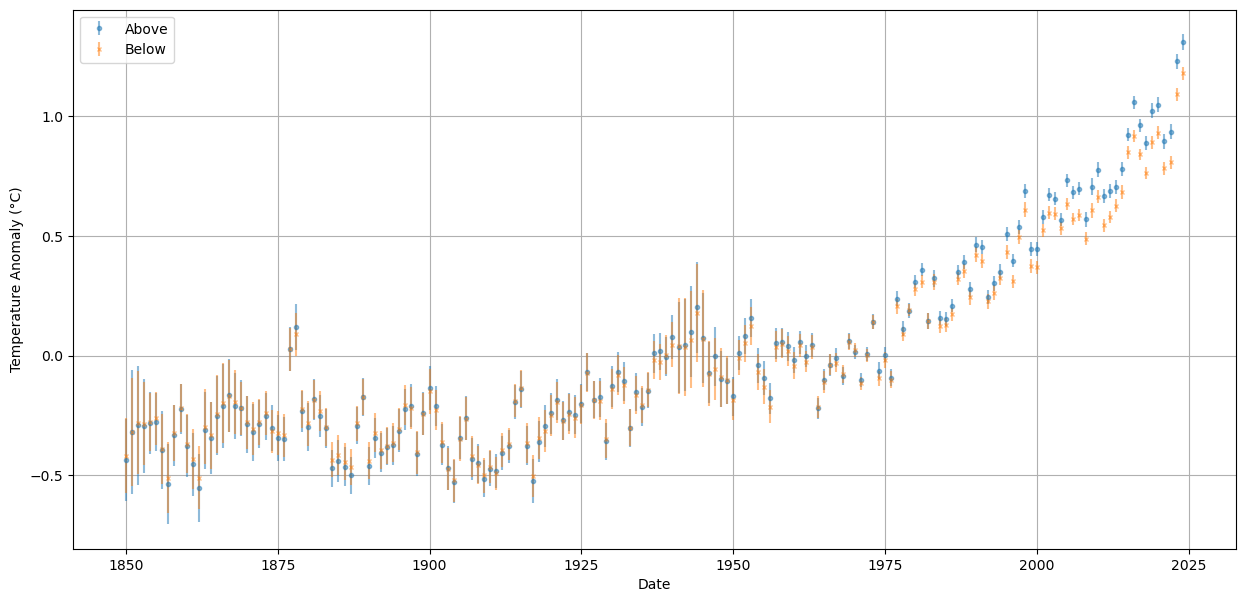

In [109]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.errorbar(df["year"], df["annual_anomaly_below"], yerr=df["annual_unc_below"], fmt="x", markersize=3, label="Below", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.savefig("results/Grafici/dati.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [110]:
# convert to np arrays for easier ingestion for ultranest
date = df["year"].values
temp_anomaly = df["annual_anomaly_above"].values
sigma2 = yerr_above ** 2

In [111]:
def constant_model(q):
    return q 

def constant_prior(cube):
    params = cube.copy()

    lower_bound = -10.0
    upper_bound = 10.0

    params[0] = lower_bound + cube[0] * (upper_bound - lower_bound)

    return params

def log_likelihood(params):
    q = params[0]
    model = constant_model(q)

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    return log_likelihood_value

parameters = [r"$q$"]

# Create results/Grafici directory
from pathlib import Path
grafici_dir = Path("results/Grafici")
grafici_dir.mkdir(parents=True, exist_ok=True)

In [112]:
sampler = ultranest.ReactiveNestedSampler(
    parameters, log_likelihood, constant_prior
)
result = sampler.run()
print(result)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+04  -27553.70 [-27553.6982..-27553.6982]*| it/evals=4760/5313 eff=96.8858% N=400 0      
[ultranest] Likelihood function evaluations: 5314
[ultranest]   logZ = -2.756e+04 +- 0.1107
[ultranest] Effective samples strategy satisfied (ESS = 1277.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.11 tail:0.03 total:0.12 required:<0.50
[ultranest] done iterating.
{'niter': 5162, 'logz': np.float64(-27562.21514620418), 'logzerr': np.float64(0.2216667553877552), 'logz_bs': np.float64(-27562.205976476762), 'logz_single': np.float64(-27562.21514620418), 'logzerr_tail': np.float64(0.033236836334253894), 'logzerr_bs': np.float64(0.21916081573726842), 'ess': np.float64(1277.3249233311658), 'H': np.float64(8.013628352269734), 'Herr': np.float64(0.10245848147026539), 'posterior': {'mea

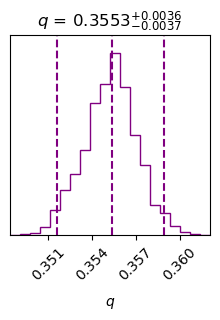

In [113]:
fig = cornerplot(
    result,
    title_fmt=".4f",
    quantiles=[0.025, 0.5, 0.975]
)
plt.savefig("results/Grafici/cornerplot_constant.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [114]:
print(result["posterior"])

{'mean': [0.35523854140938255], 'stdev': [0.001821399130861438], 'median': [0.35533743226233483], 'errlo': [0.35341118267424143], 'errup': [0.3569815832583707], 'information_gain_bits': [4.14647919764959]}


In [115]:
print(result["samples"])

[[0.35633477]
 [0.35623802]
 [0.35792451]
 ...
 [0.35491978]
 [0.35405175]
 [0.35525314]]


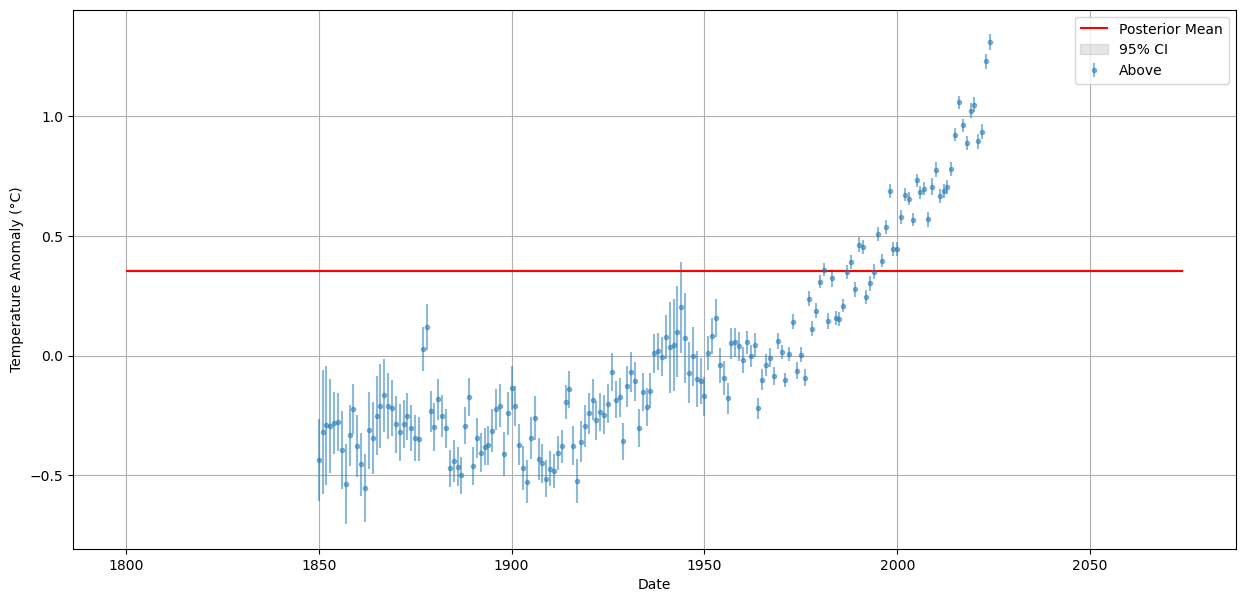

In [116]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.hlines(result["posterior"]["mean"], df["year"].min()-50, df["year"].max()+50, color="red", label="Posterior Mean")
q_samples = result["samples"][:, 0]
ci_low, ci_high = np.percentile(q_samples, [2.5, 97.5])

plt.fill_between(
    [df["year"].min()-50, df["year"].max()+50],
    ci_low,
    ci_high,
    color="gray",
    alpha=0.2,
    label="95% CI",
)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.savefig("results/Grafici/fit_constant.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [117]:
def linear_model(x, q, m):
    return q + m*x

def linear_prior(cube):
    params = cube.copy()

    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_linear_likelihood(params):
    q = params[0]
    m = params[1]
    model = linear_model(date, q, m)
    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    return log_likelihood_value

parameters_linear = [r"$q$", r"$m$"]

In [118]:
sampler_linear = ultranest.ReactiveNestedSampler(
    parameters_linear, log_linear_likelihood, linear_prior
)
result_linear = sampler_linear.run()
print(result_linear)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-6e+03  203.68 [-6203.6883..-6203.6883]*| it/evals=11816/16247 eff=74.5630% N=400   0   0    0  
[ultranest] Likelihood function evaluations: 16262
[ultranest]   logZ = -6229 +- 0.1694
[ultranest] Effective samples strategy satisfied (ESS = 1600.5, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.17, need <0.5)
[ultranest]   logZ error budget: single: 0.24 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.
{'niter': 12230, 'logz': np.float64(-6228.651179071342), 'logzerr': np.float64(0.36616963765439847), 'logz_bs': np.float64(-6228.6440154424345), 'logz_single': np.float64(-6228.651179071342), 'logzerr_tail': np.float64(0.009930404442457075), 'logzerr_bs': np.float64(0.3660349581768969), 'ess': np.float64(1600.4744050918328), 'H': np.float64(23.976965597285925), 'Herr': np.float64(0.16257269160499235), 'posterior': {'m

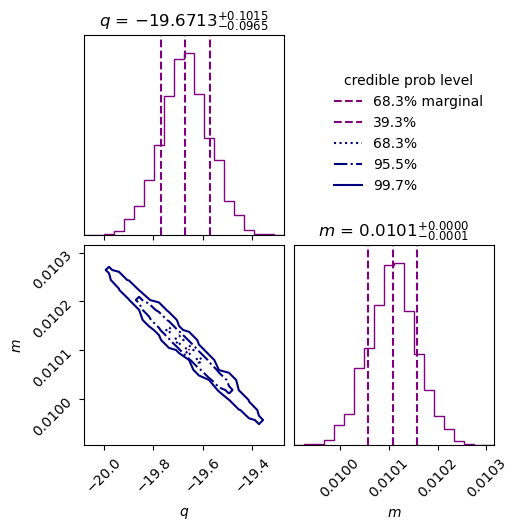

In [119]:
fig = cornerplot(
    result_linear,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.savefig("results/Grafici/cornerplot_linear.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [120]:
print(result_linear["posterior"])
print(result_linear["samples"])

{'mean': [-19.67075397715216, 0.010108369427142301], 'stdev': [0.0982151295437519, 4.9563380541732165e-05], 'median': [-19.671281998815743, 0.010108834956466417], 'errlo': [-19.76779992729962, 0.010058132749149351], 'errup': [-19.56977700500329, 0.010157144672256813], 'information_gain_bits': [4.14647919764959, 4.14647919764959]}
[[-1.96283604e+01  1.00866678e-02]
 [-1.97494717e+01  1.01466298e-02]
 [-1.95675457e+01  1.00565660e-02]
 ...
 [-1.98499700e+01  1.01991788e-02]
 [-1.96622847e+01  1.01047715e-02]
 [-1.95445826e+01  1.00448528e-02]]


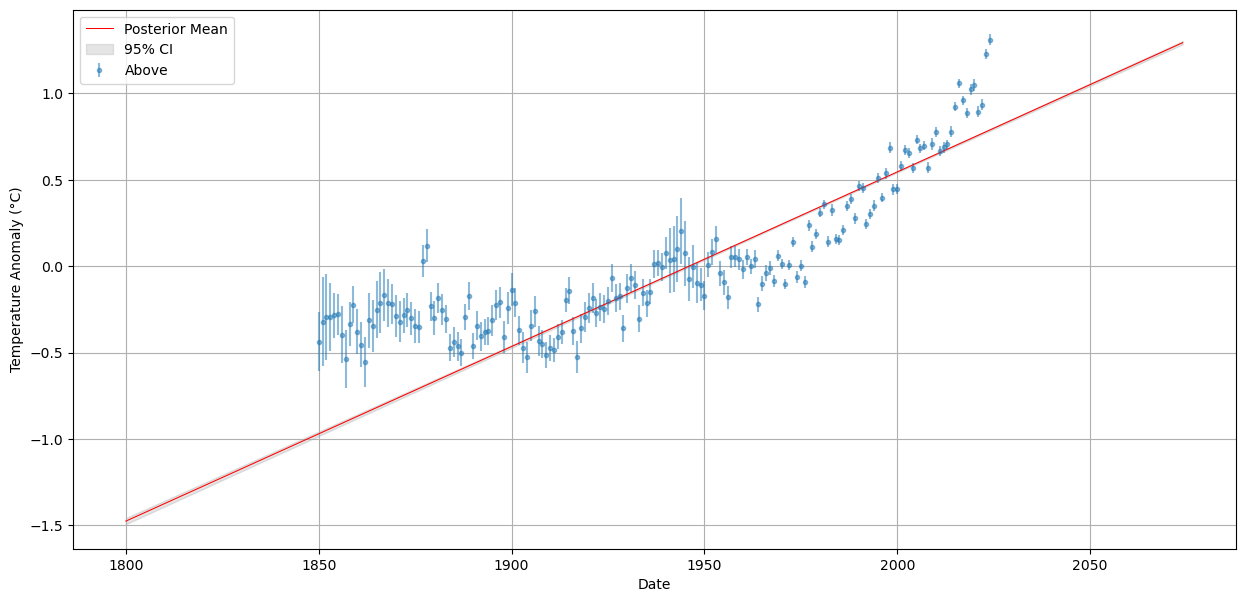

In [121]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-50, df["year"].max()+50, 100)
band = PredictionBand(year_range)

for params in result_linear["samples"]:
    q, m = params
    band.add(linear_model(year_range, q, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.savefig("results/Grafici/fit_linear.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [122]:
def exponential_model(x, q, a, m):
    # Rescale time to avoid overflow in exp for calendar-year inputs.
    t = (x - 1950.0) / 50.0
    #exponent = np.clip(m * t, -50.0, 50.0)
    return q + a * np.exp(m * t)


def exponential_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    return params


def log_exponential_likelihood(params):
    q, a, m = params
    model = exponential_model(date, q, a, m)

    if not np.all(np.isfinite(model)):
        return -1e300

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_exponential = [r"$q$", r"$a$", r"$m$"]

In [123]:
sampler_exponential = ultranest.ReactiveNestedSampler(
    parameters_exponential, log_exponential_likelihood, exponential_prior
)
result_exponential = sampler_exponential.run()
print(result_exponential)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+03  311.76 [-1311.8190..-1311.8188]*| it/evals=9600/46846 eff=20.6692% N=400 0  0  0 
[ultranest] Likelihood function evaluations: 46848
[ultranest]   logZ = -1331 +- 0.1161
[ultranest] Effective samples strategy satisfied (ESS = 1910.7, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.12 tail:0.01 total:0.12 required:<0.50
[ultranest] done iterating.
{'niter': 10003, 'logz': np.float64(-1331.1943944612456), 'logzerr': np.float64(0.23491860612406365), 'logz_bs': np.float64(-1331.2229057020777), 'logz_single': np.float64(-1331.1943944612456), 'logzerr_tail': np.float64(0.009930209822869074), 'logzerr_bs': np.float64(0.2347086330669299), 'ess': np.float64(1910.6856517443225), 'H': np.float64(17.899349416811674), 'Herr': np.float64(0.11282819557320763), 'posterior': {'mean':

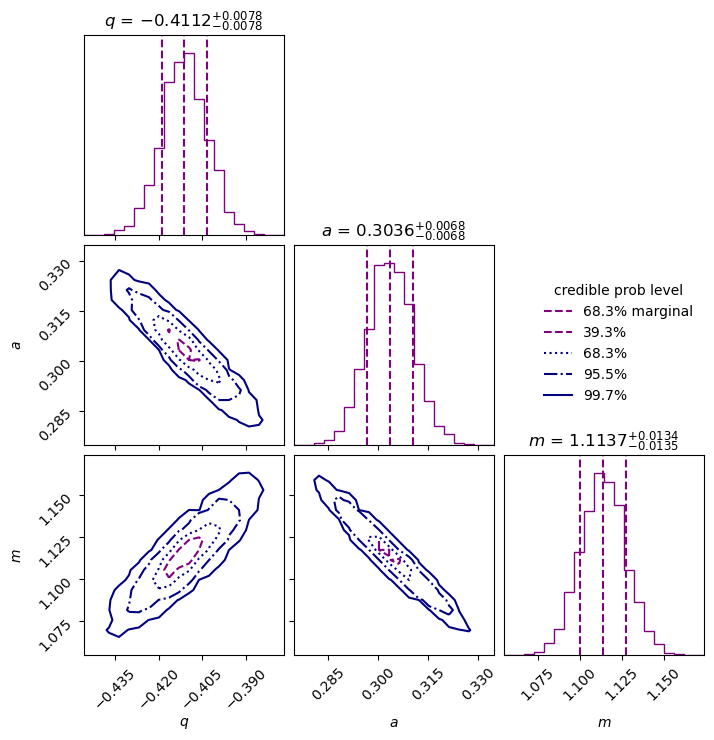

In [124]:
fig = cornerplot(
    result_exponential,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.savefig("results/Grafici/cornerplot_exponential.pdf", format="pdf", bbox_inches="tight")
plt.show()

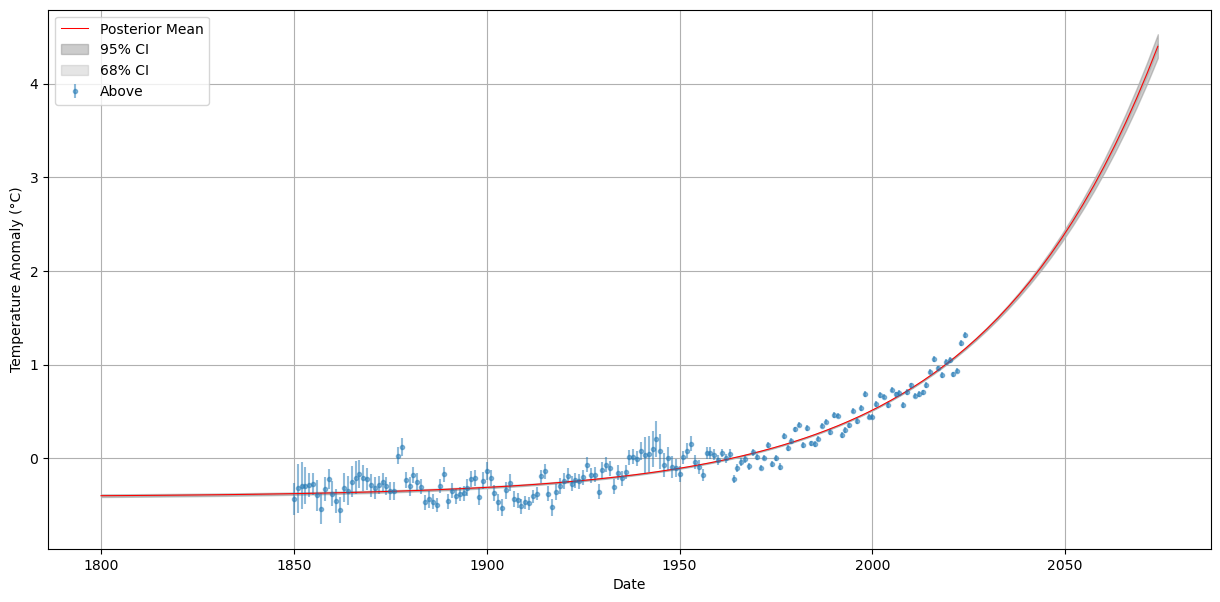

In [125]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-50, df["year"].max()+50, 100)
band = PredictionBand(year_range)

for params in result_exponential["samples"]:
    q, a, m = params
    band.add(exponential_model(year_range, q, a, m))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.4)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.savefig("results/Grafici/fit_exponential.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [126]:
print(result_exponential["posterior"])

{'mean': [-0.41114807085972555, 0.30369698969519954, 1.1138268304639696], 'stdev': [0.007792205147837031, 0.0068240839569760695, 0.013554682042468234], 'median': [-0.41113173803633485, 0.3036125223295314, 1.1137139219937628], 'errlo': [-0.4188478353603764, 0.2968388476580648, 1.1003584416590764], 'errup': [-0.40331498941532784, 0.31036210560223676, 1.1271447883133314], 'information_gain_bits': [4.146478733819291, 4.146479197647197, 3.842080218843784]}


In [127]:
'''def exponential_sine_trend(x, q, gamma, tau, a, p, phi):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + gamma * np.exp(tau * t) + a * np.sin(2 * np.pi * t / p + phi)

def gp_expsine_prior(cube):
    params = cube.copy()
    #q
    lo_0 = -0.5
    hi_0 = -0.3
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)
    #gamma
    lo_1 = 0.2
    hi_1 = 0.4
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)
    #tau
    lo_2 = 1.0
    hi_2 = 1.2
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)
    #a
    lo_3 = 1e-3
    hi_3 = 1.0
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)
    #p
    lo_4 = 5.
    hi_4 = 15.
    params[4] = lo_4 + cube[4] * (hi_4 - lo_4)
    #phi
    lo_5 = 0.0
    hi_5 = 2.0 * np.pi
    params[5] = lo_5 + cube[5] * (hi_5 - lo_5)

    return params

def log_expsine_likelihood(params):
    q, gamma, tau, a, p, phi = params
    model = exponential_sine_trend(date, q, gamma, tau, a, p, phi)

    if not np.all(np.isfinite(model)):
        return -1e300

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_expsine = ["q", "gamma", "tau", "a", "p", "phi"]'''

'def exponential_sine_trend(x, q, gamma, tau, a, p, phi):\n    t = (np.asarray(x) - 1950.0) / 50.0\n    return q + gamma * np.exp(tau * t) + a * np.sin(2 * np.pi * t / p + phi)\n\ndef gp_expsine_prior(cube):\n    params = cube.copy()\n    #q\n    lo_0 = -0.5\n    hi_0 = -0.3\n    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)\n    #gamma\n    lo_1 = 0.2\n    hi_1 = 0.4\n    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)\n    #tau\n    lo_2 = 1.0\n    hi_2 = 1.2\n    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)\n    #a\n    lo_3 = 1e-3\n    hi_3 = 1.0\n    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)\n    #p\n    lo_4 = 5.\n    hi_4 = 15.\n    params[4] = lo_4 + cube[4] * (hi_4 - lo_4)\n    #phi\n    lo_5 = 0.0\n    hi_5 = 2.0 * np.pi\n    params[5] = lo_5 + cube[5] * (hi_5 - lo_5)\n\n    return params\n\ndef log_expsine_likelihood(params):\n    q, gamma, tau, a, p, phi = params\n    model = exponential_sine_trend(date, q, gamma, tau, a, p, phi)\n\n    if not np.all(np.isfinite(model)):\n        re

In [128]:
def exponential_sine_trend(x, q, gamma, tau, A, p, B):
    t = (np.asarray(x) - 1950.0) / 50.0
    return q + gamma * np.exp(tau * t) + A * np.sin(2 * np.pi * t / p) + B * np.cos(2 * np.pi * t / p )

def gp_expsine_prior(cube):
    params = cube.copy()
    #q
    lo_0 = -2.
    hi_0 = 2.
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)
    #gamma
    lo_1 = 0.
    hi_1 = 2.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)
    #tau
    lo_2 = 0.
    hi_2 = 4.
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)
    #A
    lo_3 = -0.2
    hi_3 = 0.2
    params[3] = lo_3 + cube[3] * (hi_3 - lo_3)
    
    #p
    lo_4 = 0.1
    hi_4 = 10.
    #params[4] = lo_4 + cube[4] * (hi_4 - lo_4)
    params[4] = 10**(cube[4] * (np.log10(hi_4) - np.log10(lo_4)) + np.log10(lo_4))

    #B
    lo_5 = -0.2
    hi_5 = 0.2
    params[5] = lo_5 + cube[5] * (hi_5 - lo_5)

    return params

def log_expsine_likelihood(params):
    q, gamma, tau, A, p, B = params
    model = exponential_sine_trend(date, q, gamma, tau, A, p, B)

    if not np.all(np.isfinite(model)):
        return -1e300

    residuals = temp_anomaly - model
    log_likelihood_value = -0.5 * np.sum(
        np.log(2 * np.pi * sigma2) + (residuals ** 2) / sigma2
    )

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value

parameters_expsine = [r"$q$", r"$a$", r"$m$", r"$A$", r"$p$", r"$B$"]

In [129]:
from ultranest.stepsampler import SliceSampler, generate_mixture_random_direction
sampler_expsine = ultranest.ReactiveNestedSampler(
    parameters_expsine,
    log_expsine_likelihood,
    gp_expsine_prior
)

sampler_expsine.stepsampler = SliceSampler(
    nsteps=20,
    generate_direction=generate_mixture_random_direction
)
result_expsine = sampler_expsine.run(min_num_live_points=400, frac_remain=0.5)
print(result_expsine)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+03  102.98 [-1104.9795..-1104.9781]*| it/evals=13050/1185493 eff=1.1012% N=400     0 
[ultranest] Likelihood function evaluations: 1185493
[ultranest]   logZ = -1136 +- 0.1839
[ultranest] Effective samples strategy satisfied (ESS = 934.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.12 to 0.64, need <0.5)
[ultranest]   logZ error budget: single: 0.27 bs:0.18 tail:0.41 total:0.45 required:<0.50
[ultranest] done iterating.
{'niter': 13451, 'logz': np.float64(-1136.0671536663626), 'logzerr': np.float64(0.6232171318430164), 'logz_bs': np.float64(-1136.090631414375), 'logz_single': np.float64(-1136.0671536663626), 'logzerr_tail': np.float64(0.40551224619525783), 'logzerr_bs': np.float64(0.47324350139047056), 'ess': np.float64(934.6449556838882), 'H': np.float64(30.17536336901071), 'Herr': np.float64(0.17109158306990

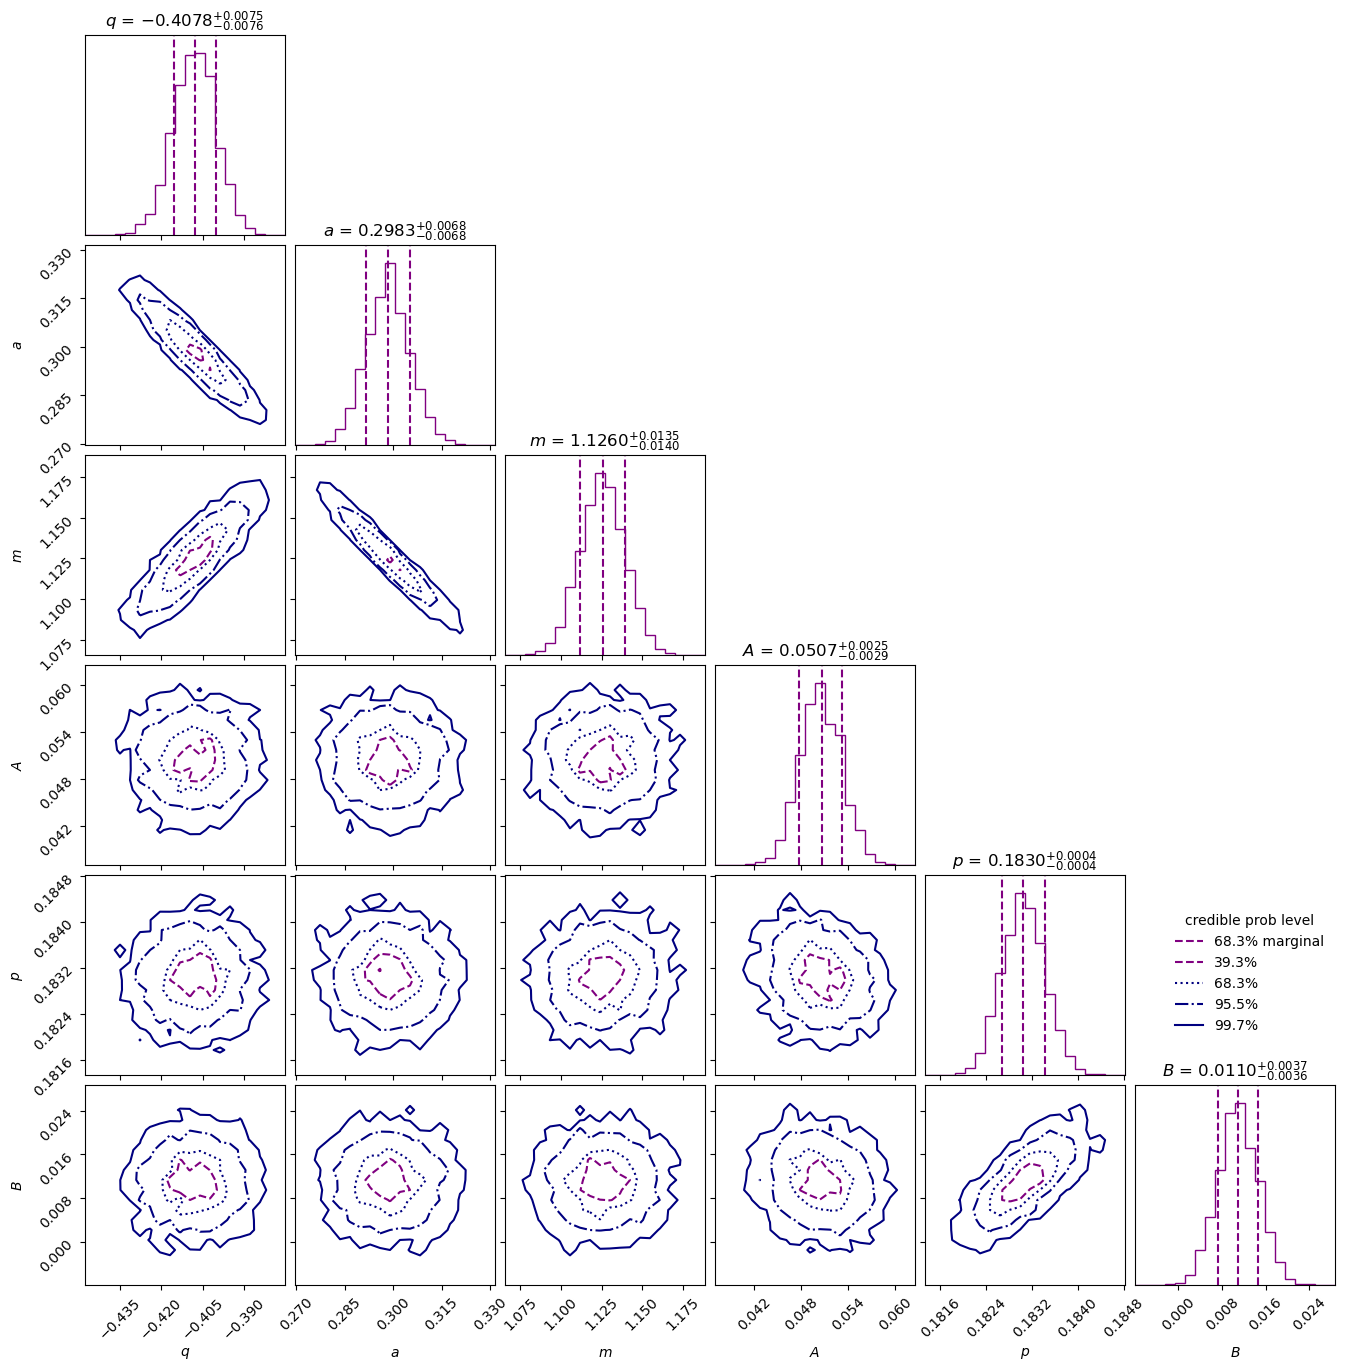

In [130]:
fig = cornerplot(
    result_expsine,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.savefig("results/Grafici/cornerplot_expsine.pdf", format="pdf", bbox_inches="tight")
plt.show()

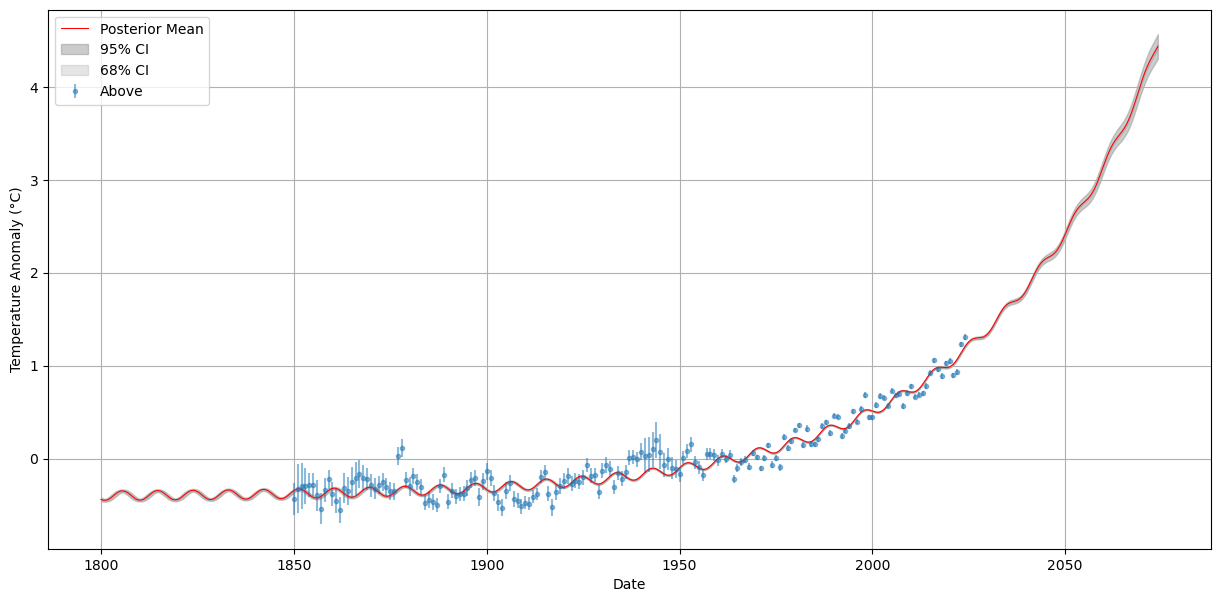

In [133]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["year"], df["annual_anomaly_above"], yerr=df["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df["year"].min()-50, df["year"].max()+50, 1000)
band = PredictionBand(year_range)

for params in result_expsine["samples"]:
    q, gamma, tau, a, p, phi = params
    band.add(exponential_sine_trend(year_range, q, gamma, tau, a, p, phi))

band.line(color="red", label="Posterior Mean", linewidth=0.75)
band.shade(color="gray", label="95% CI", q=0.475, alpha=0.4)
band.shade(color="gray", label="68% CI", q=0.16, alpha=0.2)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.savefig("results/Grafici/fit_expsine.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [135]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

to_save = {
    "result": result,
    "result_linear": result_linear,
    "result_exp": result_exponential,
    "result_expsine": result_expsine,
}

with open(out_dir / "results.pkl", "wb") as f:
    pickle.dump(to_save, f)